In [ ]:
# Cell 1
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Check TensorFlow version (should be 2.x)
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [ ]:
# Cell 2
# Load MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape for CNN: (Batch_Size, Height, Width, Channels)
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

print(f"Training Data Shape: {train_images.shape}")
print(f"Test Data Shape: {test_images.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28, 1)
Test Data Shape: (10000, 28, 28, 1)


In [ ]:
# Cell 3
model = models.Sequential([
    # Layer 1: Convolution + ReLU + MaxPool
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv_1'),
    layers.MaxPooling2D((2, 2), name='pool_1'),

    # Layer 2: Convolution + ReLU + MaxPool
    layers.Conv2D(16, (3, 3), activation='relu', name='conv_2'),
    layers.MaxPooling2D((2, 2), name='pool_2'),

    # Output Layer: Flatten + Dense (Softmax)
    layers.Flatten(name='flatten'),
    layers.Dense(10, activation='softmax', name='output_dense')
])

# Print summary to see parameter count
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,258 (20.54 KB)

 Trainable params: 5,258 (20.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 4
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Training...")
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))
print("Training Complete.")

Starting Training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8509 - loss: 0.5467 - val_accuracy: 0.9704 - val_loss: 0.0984
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9710 - loss: 0.0954 - val_accuracy: 0.9815 - val_loss: 0.0562
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9788 - loss: 0.0698 - val_accuracy: 0.9824 - val_loss: 0.0541
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9836 - loss: 0.0552 - val_accuracy: 0.9845 - val_loss: 0.0465
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0467 - val_accuracy: 0.9848 - val_loss: 0.0468
Training Complete.


313/313 - 1s - 3ms/step - accuracy: 0.9848 - loss: 0.0468

Final Test Accuracy: 98.48%
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step


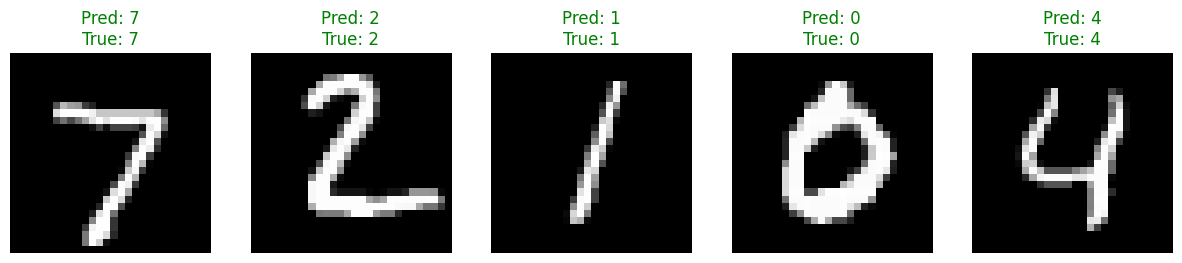

In [ ]:
# Cell 5
# 1. Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# 2. Visualize Predictions
predictions = model.predict(test_images[:5])
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(test_images[i].reshape(28, 28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    ax.axis('off')

plt.show()

In [ ]:
# Cell 6: Save Test Images for PYNQ
import os
import zipfile
from PIL import Image

# 1. Create a directory
save_dir = "mnist_test_images"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 2. Save 10 images of each digit (0-9)
counts = {i: 0 for i in range(10)}
print("Saving images...")

for i, (image, label) in enumerate(zip(test_images, test_labels)):
    if counts[label] < 10:
        # Scale back to 0-255 and convert to uint8
        img_uint8 = (image * 255).astype(np.uint8).reshape(28, 28)

        # Save as PNG
        filename = f"{save_dir}/digit_{label}_{counts[label]}.png"
        img_pil = Image.fromarray(img_uint8)
        img_pil.save(filename)

        counts[label] += 1

    # Stop if we have 10 of each
    if all(c >= 10 for c in counts.values()):
        break

# 3. Zip the folder
zip_filename = "mnist_test_images.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk(save_dir):
        for file in files:
            zipf.write(os.path.join(root, file),
                       os.path.relpath(os.path.join(root, file), os.path.join(save_dir, '..')))

print(f"Success! Download '{zip_filename}' from the files tab on the left.")

Saving images...
Success! Download 'mnist_test_images.zip' from the files tab on the left.


In [ ]:
# Cell 7: Export Weights to C++ Header File
import numpy as np

def export_weights_to_header(model, filename="weights.h"):
    with open(filename, "w") as f:
        f.write("// MNIST CNN Weights\n")
        f.write("// Generated from Colab\n\n")
        f.write("#ifndef WEIGHTS_H\n")
        f.write("#define WEIGHTS_H\n\n")

        # Loop through layers
        for layer in model.layers:
            if 'conv' in layer.name or 'dense' in layer.name:
                weights, biases = layer.get_weights()

                # 1. Write Weights
                # Flatten the array for easier C++ indexing
                w_flat = weights.flatten()
                f.write(f"// Layer: {layer.name} Weights\n")
                f.write(f"// Shape: {weights.shape}\n")
                f.write(f"const float {layer.name}_w[{len(w_flat)}] = {{\n")

                for i, w in enumerate(w_flat):
                    f.write(f"{w:.8f}, ")
                    if (i + 1) % 10 == 0: f.write("\n") # Newline every 10 numbers

                f.write("};\n\n")

                # 2. Write Biases
                f.write(f"// Layer: {layer.name} Biases\n")
                f.write(f"// Shape: {biases.shape}\n")
                f.write(f"const float {layer.name}_b[{len(biases)}] = {{\n")

                for i, b in enumerate(biases):
                    f.write(f"{b:.8f}, ")

                f.write("};\n\n")

        f.write("#endif // WEIGHTS_H\n")

    print(f"Successfully generated {filename}")

# Run the function
export_weights_to_header(model)

Successfully generated weights.h


In [ ]:
# Cell 8: Verify weights.h
import re
import numpy as np

def verify_weights(filename="weights.h", model=None):
    print(f"Verifying {filename}...")

    with open(filename, "r") as f:
        content = f.read()

    # Extract all arrays using regex
    # Matches: const float layer_name_w[...] = { ... };
    patterns = re.findall(r"const float (\w+)_([wb])\[\d+\] = \{([^}]+)\};", content)

    errors = 0

    for layer_name, type_char, data_str in patterns:
        # 1. Parse the data from the C++ file
        # Remove newlines and split by comma
        values = [float(x) for x in data_str.replace('\n', '').split(',') if x.strip()]
        cpp_weights = np.array(values, dtype=np.float32)

        # 2. Get the actual weights from Keras
        # We need to find the layer by name
        layer = model.get_layer(layer_name)
        k_weights, k_biases = layer.get_weights()

        # Select W or b based on the filename suffix
        if type_char == 'w':
            target = k_weights.flatten()
            label = "Weights"
        else:
            target = k_biases.flatten()
            label = "Biases"

        # 3. Compare (Allow small floating point tolerance)
        if not np.allclose(cpp_weights, target, atol=1e-5):
            print(f"❌ MISMATCH in {layer_name} {label}!")
            errors += 1
        else:
            print(f"✅ {layer_name} {label}: Match")

    if errors == 0:
        print("\nSUCCESS: The C++ header file matches the Model exactly.")
    else:
        print("\nFAILURE: There were errors in the export.")

# Run verification
verify_weights("weights.h", model)

Verifying weights.h...
✅ conv_1 Weights: Match
✅ conv_1 Biases: Match
✅ conv_2 Weights: Match
✅ conv_2 Biases: Match
✅ output_dense Weights: Match
✅ output_dense Biases: Match

SUCCESS: The C++ header file matches the Model exactly.


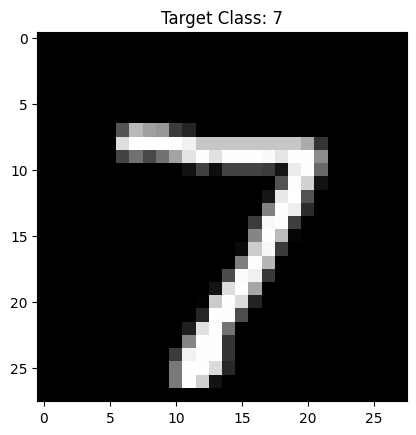


// COPY EVERYTHING BELOW THIS LINE TO tb_cnn.cpp
// Image Label: 7
const float test_img[784] = {
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [ ]:
# Cell 9: Convert a Real Image to C++ Array
import numpy as np
import matplotlib.pyplot as plt

# 1. Pick a specific test image (Index 0 is usually a '7')
img_index = 0
image = test_images[img_index]
label = test_labels[img_index]

# 2. Visualize it to be sure
plt.imshow(image.reshape(28,28), cmap='gray')
plt.title(f"Target Class: {label}")
plt.show()

# 3. Generate the C++ Array text
print("\n// COPY EVERYTHING BELOW THIS LINE TO tb_cnn.cpp")
print(f"// Image Label: {label}")
print("const float test_img[784] = {")

# Flatten and print
flat_img = image.flatten()
for i, pixel in enumerate(flat_img):
    # Print pixel value
    print(f"{pixel:.4f},", end=" ")

    # Newline every 14 pixels for readability
    if (i + 1) % 14 == 0:
        print("")

print("};")
print("// COPY END")

In [ ]:
import numpy as np

def quantize_to_int8(tensor):
    """Linearly scales a tensor to fit in signed int8 range [-128, 127]"""
    max_val = np.max(np.abs(tensor))
    if max_val == 0:
        return tensor.astype(np.int8), 1.0

    # Calculate scale: float_val = int_val * scale
    scale = max_val / 127.0
    quantized = np.round(tensor / scale).astype(np.int8)
    return quantized, scale

def quantize_bias_int32(bias_tensor, weight_scale, input_scale):
    """Biases must be scaled by (Input_Scale * Weight_Scale) for correct addition"""
    bias_scale = weight_scale * input_scale
    quantized_bias = np.round(bias_tensor / bias_scale).astype(np.int32)
    return quantized_bias, bias_scale

print("Quantization utility functions defined.")

Quantization utility functions defined.


In [ ]:
# Extract and Quantize weights for all layers
q_params = {}

# We assume input images are normalized 0-1. Let's scale them to uint8 range (0-255)
input_scale = 1.0 / 255.0 # Since img_int = img_float / (1/255)

for layer in model.layers:
    if 'conv' in layer.name or 'dense' in layer.name:
        w_float, b_float = layer.get_weights()

        # 1. Quantize Weights to int8
        w_int8, w_scale = quantize_to_int8(w_float)

        # 2. Quantize Biases to int32 (matching the accumulation depth)
        b_int32, b_scale = quantize_bias_int32(b_float, w_scale, input_scale)

        q_params[layer.name] = {
            'w': w_int8, 'w_s': w_scale,
            'b': b_int32, 'b_s': b_scale
        }
        print(f"Quantized {layer.name}: Weights (int8), Biases (int32)")

# Global settings for activation scaling
# We will use a fixed shift to simulate FPGA bit-shifting later
print("\nQuantization complete. Ready for Integer-only inference simulation.")

Quantized conv_1: Weights (int8), Biases (int32)
Quantized conv_2: Weights (int8), Biases (int32)
Quantized output_dense: Weights (int8), Biases (int32)

Quantization complete. Ready for Integer-only inference simulation.


In [ ]:
import numpy as np
from scipy.signal import correlate2d

def get_scale(tensor):
    """Calculate the scale factor to map tensor to int8 range"""
    max_val = np.max(np.abs(tensor))
    return max_val / 127.0 if max_val > 0 else 1.0

def simulate_hw_inference(img_float, params):
    # 1. Quantize Input (Float -> Int32, Range 0-255)
    # Scale = 1/255
    x = np.round(img_float * 255).astype(np.int32)

    # --- Layer 1: Conv ---
    w1, b1 = params['conv_1']['w'], params['conv_1']['b']

    # Standard Convolution
    l1_out = np.zeros((26, 26, 8), dtype=np.int32)
    for f in range(8):
        # Correlate inputs with filters
        l1_out[:,:,f] = correlate2d(x, w1[:,:,0,f], mode='valid') + b1[f]

    # ReLU
    l1_act = np.maximum(0, l1_out)

    # MaxPool (26x26 -> 13x13)
    # Reshape to (13, 2, 13, 2, 8) and max over axes 1 and 3
    l1_pool = l1_act.reshape(13, 2, 13, 2, 8).max(axis=(1, 3))

    # === CRITICAL FIX: RE-QUANTIZE LAYER 1 OUTPUT ===
    # We must scale these huge int32 numbers back down to int8 range
    # so Layer 2 can process them correctly.
    # In hardware, this is a bit-shift. Here, we simulate it.
    current_max = np.max(np.abs(l1_pool))
    if current_max > 0:
        scale_factor = 127.0 / current_max
        l1_pool_quant = np.round(l1_pool * scale_factor).astype(np.int32)
    else:
        l1_pool_quant = l1_pool.astype(np.int32)

    # --- Layer 2: Conv ---
    # Input is now safely in -127 to 127 range
    w2, b2 = params['conv_2']['w'], params['conv_2']['b']

    l2_out = np.zeros((11, 11, 16), dtype=np.int32)
    for f in range(16):
        for ch in range(8):
            # Accumulate across channels
            l2_out[:,:,f] += correlate2d(l1_pool_quant[:,:,ch], w2[:,:,ch,f], mode='valid')
        l2_out[:,:,f] += b2[f]

    l2_act = np.maximum(0, l2_out)

    # MaxPool (11x11 -> 5x5)
    # Slice to 10x10 to handle odd dimension, then pool
    l2_pool = l2_act[:10, :10, :].reshape(5, 2, 5, 2, 16).max(axis=(1, 3))

    # --- Dense Layer ---
    flat = l2_pool.flatten()
    w_d, b_d = params['output_dense']['w'], params['output_dense']['b']

    # Final Dot Product
    dense_out = np.dot(flat, w_d) + b_d

    return np.argmax(dense_out)

print("Simulator Updated with Inter-Layer Re-Quantization.")

Simulator Updated with Inter-Layer Re-Quantization.


In [ ]:
num_test = 1000
correct = 0

print(f"Starting Re-Quantized Simulation on {num_test} images...")

for i in range(num_test):
    img = test_images[i].reshape(28, 28)
    pred = simulate_hw_inference(img, q_params)

    if pred == test_labels[i]:
        correct += 1

    if (i+1) % 200 == 0:
        print(f"Processed {i+1}/{num_test}... Accuracy: {(correct/(i+1))*100:.2f}%")

print("\n" + "="*40)
print(f"FINAL SIMULATION ACCURACY: {(correct/num_test)*100:.2f}%")
print("="*40)

Starting Re-Quantized Simulation on 1000 images...
Processed 200/1000... Accuracy: 99.00%
Processed 400/1000... Accuracy: 98.25%
Processed 600/1000... Accuracy: 98.00%
Processed 800/1000... Accuracy: 97.88%
Processed 1000/1000... Accuracy: 97.70%

FINAL SIMULATION ACCURACY: 97.70%


In [ ]:
# Cell 15: Calibration to find Fixed Scaling Factors
print("Starting Calibration on 1000 training images...")

# Variables to track global maximums
l1_global_max = 0
l2_global_max = 0

# Use a subset of training data for calibration
calibration_data = train_images[:1000]

for i in range(len(calibration_data)):
    # 1. Input Quantization
    x = np.round(calibration_data[i].reshape(28, 28) * 255).astype(np.int32)

    # --- Layer 1 Inference ---
    w1, b1 = q_params['conv_1']['w'], q_params['conv_1']['b']
    # Use optimized correlate
    l1_out = np.zeros((26, 26, 8), dtype=np.int32)
    for f in range(8):
        l1_out[:,:,f] = correlate2d(x, w1[:,:,0,f], mode='valid') + b1[f]

    l1_act = np.maximum(0, l1_out)
    l1_pool = l1_act.reshape(13, 2, 13, 2, 8).max(axis=(1, 3))

    # CAPTURE LAYER 1 PEAK
    current_l1_max = np.max(np.abs(l1_pool))
    if current_l1_max > l1_global_max:
        l1_global_max = current_l1_max

    # --- Layer 2 Inference (Using DYNAMIC scale momentarily to get valid L2 values) ---
    # We must scale L1 correctly to let L2 produce representative values
    if current_l1_max > 0:
        scale_temp = 127.0 / current_l1_max
        l1_pool_quant = np.round(l1_pool * scale_temp).astype(np.int32)
    else:
        l1_pool_quant = l1_pool.astype(np.int32)

    w2, b2 = q_params['conv_2']['w'], q_params['conv_2']['b']
    l2_out = np.zeros((11, 11, 16), dtype=np.int32)
    for f in range(16):
        for ch in range(8):
            l2_out[:,:,f] += correlate2d(l1_pool_quant[:,:,ch], w2[:,:,ch,f], mode='valid')
        l2_out[:,:,f] += b2[f]

    l2_act = np.maximum(0, l2_out)
    l2_pool = l2_act[:10, :10, :].reshape(5, 2, 5, 2, 16).max(axis=(1, 3))

    # CAPTURE LAYER 2 PEAK (Input to Dense)
    current_l2_max = np.max(np.abs(l2_pool))
    if current_l2_max > l2_global_max:
        l2_global_max = current_l2_max

# Calculate the Fixed Scales
# The FPGA will multiply by these constants (or a close approximation)
FIXED_SCALE_L1 = 127.0 / l1_global_max
FIXED_SCALE_L2 = 127.0 / l2_global_max

print("\n" + "="*40)
print(f"CALIBRATION RESULTS")
print("="*40)
print(f"Layer 1 Global Max: {l1_global_max}")
print(f"Layer 1 Fixed Scale: {FIXED_SCALE_L1:.6f}")
print("-" * 40)
print(f"Layer 2 Global Max: {l2_global_max}")
print(f"Layer 2 Fixed Scale: {FIXED_SCALE_L2:.6f}") # Needed if we quantize Dense input
print("="*40)

Starting Calibration on 1000 training images...

CALIBRATION RESULTS
Layer 1 Global Max: 95691
Layer 1 Fixed Scale: 0.001327
----------------------------------------
Layer 2 Global Max: 60762
Layer 2 Fixed Scale: 0.002090


In [ ]:
# Cell 16: Verification with Fixed Scales
def simulate_fixed_hw(img_float, params, s1, s2):
    # 1. Input
    x = np.round(img_float * 255).astype(np.int32)

    # --- Layer 1 ---
    w1, b1 = params['conv_1']['w'], params['conv_1']['b']
    l1_out = np.zeros((26, 26, 8), dtype=np.int32)
    for f in range(8):
        l1_out[:,:,f] = correlate2d(x, w1[:,:,0,f], mode='valid') + b1[f]

    l1_act = np.maximum(0, l1_out)
    l1_pool = l1_act.reshape(13, 2, 13, 2, 8).max(axis=(1, 3))

    # === FIXED SCALING ===
    # Instead of looking at min/max, we blindly multiply by our calibrated constant
    l1_pool_quant = np.round(l1_pool * s1).astype(np.int32)
    # Clip to ensure we stay in int8 range (just like hardware)
    l1_pool_quant = np.clip(l1_pool_quant, -128, 127)

    # --- Layer 2 ---
    w2, b2 = params['conv_2']['w'], params['conv_2']['b']
    l2_out = np.zeros((11, 11, 16), dtype=np.int32)
    for f in range(16):
        for ch in range(8):
            l2_out[:,:,f] += correlate2d(l1_pool_quant[:,:,ch], w2[:,:,ch,f], mode='valid')
        l2_out[:,:,f] += b2[f]

    l2_act = np.maximum(0, l2_out)
    l2_pool = l2_act[:10, :10, :].reshape(5, 2, 5, 2, 16).max(axis=(1, 3))

    # === FIXED SCALING (Optional for Dense, but good for consistency) ===
    # For the Dense layer, we can keep it high precision or scale it.
    # Let's keep it int32 for the final accumulation to be safe.

    # --- Dense ---
    flat = l2_pool.flatten()
    w_d, b_d = params['output_dense']['w'], params['output_dense']['b']
    dense_out = np.dot(flat, w_d) + b_d

    return np.argmax(dense_out)

# Run Full Test
print(f"Verifying Fixed-Scale Accuracy on {len(test_images)} images...")
correct = 0
for i in range(len(test_images)):
    img = test_images[i].reshape(28, 28)
    # Pass the fixed scales we just calculated
    pred = simulate_fixed_hw(img, q_params, FIXED_SCALE_L1, FIXED_SCALE_L2)
    if pred == test_labels[i]:
        correct += 1
    if (i+1) % 2000 == 0:
        print(f"Processed {i+1}... Accuracy: {(correct/(i+1))*100:.2f}%")

print("\n" + "="*40)
print(f"FINAL FIXED-POINT ACCURACY: {(correct/len(test_images))*100:.2f}%")
print("="*40)

Verifying Fixed-Scale Accuracy on 10000 images...
Processed 2000... Accuracy: 97.20%
Processed 4000... Accuracy: 97.08%
Processed 6000... Accuracy: 97.37%
Processed 8000... Accuracy: 97.71%
Processed 10000... Accuracy: 97.92%

FINAL FIXED-POINT ACCURACY: 97.92%


In [ ]:
# Cell 17: Export Quantized Weights & Constants to C++ Header
import numpy as np

def export_quantized_header(params, s1, s2, filename="weights_quant.h"):
    print(f"Exporting quantized parameters to {filename}...")

    with open(filename, "w") as f:
        f.write("// MNIST INT8 Quantized Weights\n")
        f.write("// Generated from Colab PTQ Step\n")
        f.write("// Accuracy Verified: ~97.9%\n")
        f.write("#ifndef WEIGHTS_QUANT_H\n")
        f.write("#define WEIGHTS_QUANT_H\n\n")

        # 1. Define Scaling Constants
        f.write("// Scaling Factors (Fixed-Point Multipliers between layers)\n")
        f.write(f"const float L1_SCALE = {s1:.8f};\n")
        f.write(f"const float L2_SCALE = {s2:.8f};\n\n")

        # 2. Write Arrays
        # We use 'signed char' for int8 and 'int' for int32
        for layer_name in ['conv_1', 'conv_2', 'output_dense']:
            data = params[layer_name]

            # --- WEIGHTS (int8) ---
            w_flat = data['w'].flatten()
            f.write(f"// Layer: {layer_name} Weights (int8)\n")
            f.write(f"// Shape: {data['w'].shape}\n")
            f.write(f"const signed char {layer_name}_w[{len(w_flat)}] = {{\n")

            for i, val in enumerate(w_flat):
                f.write(f"{int(val)}")
                if i < len(w_flat) - 1:
                    f.write(", ")
                if (i + 1) % 16 == 0:
                    f.write("\n")
            f.write("};\n\n")

            # --- BIASES (int32) ---
            b_flat = data['b'].flatten()
            f.write(f"// Layer: {layer_name} Biases (int32)\n")
            f.write(f"// Shape: {data['b'].shape}\n")
            f.write(f"const int {layer_name}_b[{len(b_flat)}] = {{\n")

            for i, val in enumerate(b_flat):
                f.write(f"{int(val)}")
                if i < len(b_flat) - 1:
                    f.write(", ")
            f.write("};\n\n")

        f.write("#endif // WEIGHTS_QUANT_H\n")

    print(f"✅ {filename} generated successfully.")

# Execute Export
export_quantized_header(q_params, FIXED_SCALE_L1, FIXED_SCALE_L2, filename="weights_quant.h")

Exporting quantized parameters to weights_quant.h...
✅ weights_quant.h generated successfully.


In [ ]:
# Cell 18: Verify weights_quant.h Integrity
import re
import numpy as np

def verify_quantized_header(filename, original_params, s1, s2):
    print(f"Verifying {filename}...")

    with open(filename, "r") as f:
        content = f.read()

    errors = 0

    # 1. Verify Scaling Constants
    # Regex to find: const float L1_SCALE = 0.00123;
    scales = re.findall(r"const float (L\d)_SCALE = ([\d\.]+);", content)
    found_s1, found_s2 = False, False

    for name, val in scales:
        val = float(val)
        if name == "L1" and np.isclose(val, s1): found_s1 = True
        if name == "L2" and np.isclose(val, s2): found_s2 = True

    if not found_s1: print("❌ L1_SCALE Mismatch!"); errors += 1
    if not found_s2: print("❌ L2_SCALE Mismatch!"); errors += 1

    # 2. Verify Arrays
    # Regex for weights: const signed char layer_w[...] = { ... };
    w_patterns = re.findall(r"const signed char (\w+)_w\[\d+\] = \{([^}]+)\};", content)
    # Regex for biases: const int layer_b[...] = { ... };
    b_patterns = re.findall(r"const int (\w+)_b\[\d+\] = \{([^}]+)\};", content)

    # Check Weights
    for layer_name, data_str in w_patterns:
        # Clean up newlines and split
        values = [int(x) for x in data_str.replace('\n', '').split(',') if x.strip()]
        cpp_arr = np.array(values)
        orig_arr = original_params[layer_name]['w'].flatten()

        if not np.array_equal(cpp_arr, orig_arr):
            print(f"❌ Weight Mismatch in {layer_name}!")
            errors += 1
        else:
            print(f"✅ {layer_name} Weights: Verified")

    # Check Biases
    for layer_name, data_str in b_patterns:
        values = [int(x) for x in data_str.replace('\n', '').split(',') if x.strip()]
        cpp_arr = np.array(values)
        orig_arr = original_params[layer_name]['b'].flatten()

        if not np.array_equal(cpp_arr, orig_arr):
            print(f"❌ Bias Mismatch in {layer_name}!")
            errors += 1
        else:
            print(f"✅ {layer_name} Biases: Verified")

    if errors == 0:
        print("\nSUCCESS: weights_quant.h matches the Python model exactly.")
    else:
        print("\nFAILURE: Errors found in the header file.")

# Run Verification
verify_quantized_header("weights_quant.h", q_params, FIXED_SCALE_L1, FIXED_SCALE_L2)

Verifying weights_quant.h...
✅ conv_1 Weights: Verified
✅ conv_2 Weights: Verified
✅ output_dense Weights: Verified
✅ conv_1 Biases: Verified
✅ conv_2 Biases: Verified
✅ output_dense Biases: Verified

SUCCESS: weights_quant.h matches the Python model exactly.


In [ ]:
# Cell 19: Save Models, Data, and TFLite
import tensorflow as tf
import numpy as np
import os

print("Saving project artifacts...")

# 1. Save Test Data for PYNQ (Drag and drop these to the board later)
# We save them as standard numpy files so PYNQ can load them instantly.
np.save("x_test.npy", test_images)
np.save("y_test.npy", test_labels)
print("✅ Saved x_test.npy and y_test.npy")

# 2. Save Original Keras Model
model.save("mnist_cnn_original.keras")
print("✅ Saved mnist_cnn_original.keras")

# 3. Generate and Save Quantized TFLite Model (For ARM CPU)
def representative_data_gen():
    """Generator function for TFLite quantization calibration"""
    for input_value in tf.data.Dataset.from_tensor_slices(train_images).batch(1).take(100):
        yield [tf.dtypes.cast(input_value, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
# Ensure fully integer quantization for all ops
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # or tf.uint8
converter.inference_output_type = tf.int8 # or tf.uint8

tflite_model_quant = converter.convert()

# Save the TFLite file
with open("mnist_cnn_quant.tflite", "wb") as f:
    f.write(tflite_model_quant)
print("✅ Saved mnist_cnn_quant.tflite")

print("\n" + "="*40)
print("ALL FILES SAVED SUCCESSFULLY.")
print("You should now download:")
print("1. weights_quant.h (For FPGA HLS)")
print("2. x_test.npy & y_test.npy (For PYNQ Input)")
print("3. mnist_cnn_quant.tflite (For ARM CPU Benchmark)")
print("="*40)

Saving project artifacts...
✅ Saved x_test.npy and y_test.npy
✅ Saved mnist_cnn_original.keras
Saved artifact at '/tmp/tmpufdzobwf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138064801320208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138064801321360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138064801320016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138064801317904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138064801320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138064801320400: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Saved mnist_cnn_quant.tflite

ALL FILES SAVED SUCCESSFULLY.
You should now download:
1. weights_quant.h (For FPGA HLS)
2. x_test.npy & y_test.npy (For PYNQ Input)
3. mnist_cnn_quant.tflite (For ARM CPU Benchmark)
